In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.95MB/s]


In [3]:
class SimpleNN (nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Flatten (), #تسطيح 28x28 =784 #INPUT layer
        nn.Linear(784, 677), #HIDDEN layer
        nn.Linear(677, 590), #النموذج المدرب
        nn.ReLU(),#activation function
        nn.Linear(590, 10)  # 10 classes #output
    )
  def forward(self, x):
    return self.model(x)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
for epoch in range(3):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done


In [6]:
torch.save(model.state_dict(), "model.pth") # save model weights

In [7]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Accuracy:", 100 * correct / total)

Accuracy: 97.0


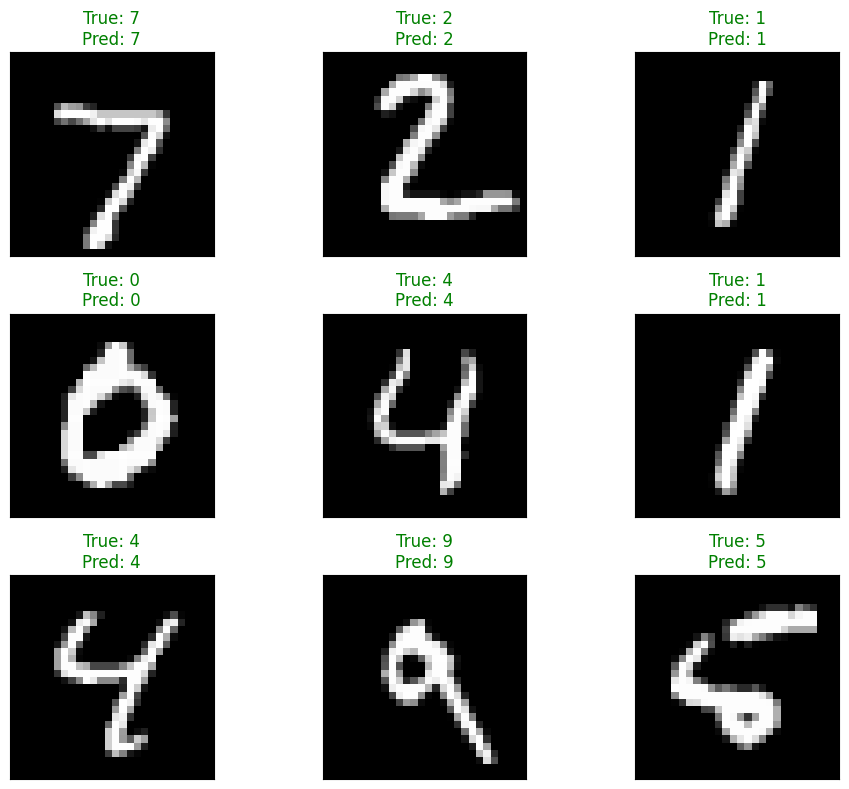

In [8]:
import matplotlib.pyplot as plt

# Get a batch of test images and labels
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move to device
images, labels = images.to(device), labels.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# Display some images with predictions and true labels
fig = plt.figure(figsize=(10, 8))
for i in range(9):
    ax = fig.add_subplot(3, 3, i + 1, xticks=[], yticks=[])
    # Convert image to numpy array for displaying
    img = images[i].cpu().numpy().squeeze()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {labels[i].item()}\nPred: {preds[i].item()}",
                 color=("green" if preds[i] == labels[i] else "red"))
plt.tight_layout()
plt.show()

In [10]:
!pip install gradio -q

In [13]:
import torch
import torch.nn as nn
from torchvision import transforms
import gradio as gr
from PIL import Image, ImageOps

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNN().to(device)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

def predict_digit(image):
    if image is None:
        return None

    img = image["composite"].convert('L')

    img = ImageOps.invert(img)

    img = img.resize((28, 28))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)

    return {str(i): float(probabilities[i]) for i in range(10)}

interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(type="pil", label="Draw a digit"),
    outputs=gr.Label(label="Result", num_top_classes=1),
    title="MNIST Handwritten Digit Recognition",
    description="Draw a digit from 0 to 9 and click Submit."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://95b0af25eee54f29b8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


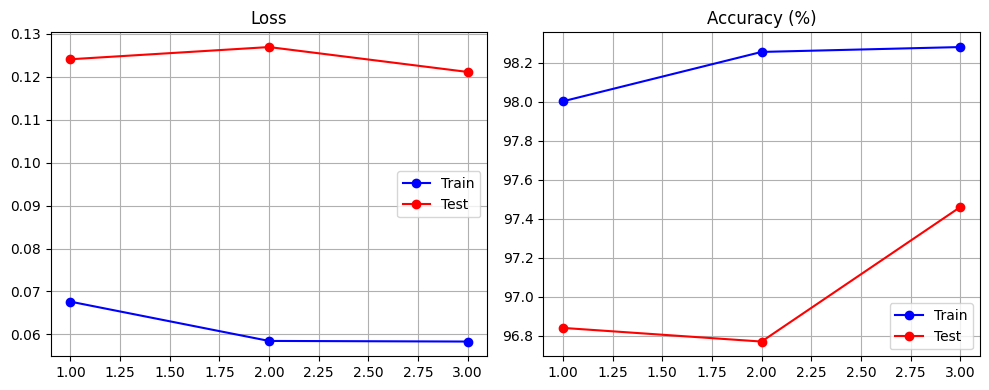

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(3):

    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += lbls.size(0)
    train_losses.append(loss_sum / total)
    train_accs.append((correct / total) * 100)

    model.eval()
    t_loss_sum, t_correct, t_total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            t_loss_sum += criterion(out, lbls).item() * imgs.size(0)
            t_correct += (out.argmax(1) == lbls).sum().item()
            t_total += lbls.size(0)
    test_losses.append(t_loss_sum / t_total)
    test_accs.append((t_correct / t_total) * 100)

torch.save(model.state_dict(), "model.pth")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot([1, 2, 3], train_losses, 'b-o', label='Train')
ax1.plot([1, 2, 3], test_losses, 'r-o', label='Test')
ax1.set_title('Loss')
ax1.legend(); ax1.grid(True)

ax2.plot([1, 2, 3], train_accs, 'b-o', label='Train')
ax2.plot([1, 2, 3], test_accs, 'r-o', label='Test')
ax2.set_title('Accuracy (%)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()